In [ ]:
# =============================================================
# Nombre del archivo: dataCorrelationOutliers.py
# Autora: Mónica Monserrat Martínez Vásquez
# Fecha de creación original: 22-10-2025
# Última edición: 5-11-2025
#
# Descripción:
#   Este script realiza un análisis de correlación entre diversas
#   características morfológicas y productivas del ganado lechero,
#   enfocándose en la relación con la condición corporal expresada
#   por el índice BWC (Body Weight Composite), utilizado como
#   aproximación numérica del puntaje de condición corporal (BCS).
#
# Dependencias: pandas, numpy, matplotlib, seaborn, statsmodels, sklearn
# =============================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Carga del dataset desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta y carga de datos
path = '/content/drive/MyDrive/Equipo 5/3. Data Preparation/codigos de colab'
if not os.path.exists(path):
    print(f"La ruta no existe. Asegúrate de que la ruta '{path}' es correcta.")
else:
    print(f"Ruta de imágenes configurada a: {path}")

Ruta de imágenes configurada a: /content/drive/MyDrive/Equipo 5/3. Data Preparation/codigos de colab


In [ ]:
# Carga el archivo CSV con los valores morfológicos/productivos
selectSiresDf = pd.read_csv(os.path.join(path, 'interestingTraits.csv'))
display(selectSiresDf.head())

,SCS,MAST,UDC,STR,DFM,RUA,RLS,RTP,FTL,FI,...,RW,RLR,FTA,FUA,RUH,RUW,UCL,UDP,FTP,Sire Stack
2.83,2.3,0.62,1.39,1.05,0.06,1.50,0.09,0.55,0.3,1.13,...,0.25,0.42,1.26,0.79,1.33,0.07,0.80,0.22,Sheepster x Deluxe x Biggelo,NaN
2.84,1.5,0.98,-0.23,1.52,0.27,0.72,0.76,-0.41,0.7,-0.60,...,0.14,0.26,0.92,1.48,1.61,0.47,0.54,0.44,Sheepster x Gameday x Legacy,NaN
2.66,3.5,0.43,-0.75,1.38,0.54,0.35,-0.81,-0.32,0.4,-1.18,...,-0.52,-0.45,0.73,0.39,0.80,-0.28,0.59,-0.36,Rimbot x Monteverdi x Envoy,NaN
2.78,2.9,0.89,0.05,0.21,-0.41,-0.02,0.40,-0.03,1.6,-0.03,...,0.96,0.50,0.87,0.96,1.10,0.32,0.51,0.31,Sheepster x Gameday x Pursuit,NaN
2.79,2.5,0.52,-0.73,0.04,0.60,0.71,0.00,-0.62,1.1,-0.72,...,0.15,-0.23,0.77,0.29,0.44,-0.18,0.51,0.14,Sheepster x Gameday x Legacy,NaN


In [ ]:
print("Number of rows and columns:", selectSiresDf.shape)

Number of rows and columns: (368, 22)


In [ ]:
"""
Variables morfológicas y productivas relacionadas con BWC:

RW: Rump Width
RUH: Rear Udder Height
RUW: Rear Udder Width
STR: Strength
SCS: Somatic Cell Score (salud de ubre)
MAST: Mastitis Resistance
UDP: Udder Depth
UDC: Udder Composite
DFM: Dairy Form
RUA: Rear Udder Attachment
FI: Fertility Index
BWC: Body Weight Composite (variable objetivo)
RLR: Rear Leg Rear View
FUA: Fore Udder Attachment
BOD: Body Depth
RLS: Rear Leg Side View
FTA: Foot Angle
RTP: Rear Teat Placement
UCL: Udder Cleft
"""

In [ ]:
# Selección y validación de columnas
columnsToKeep = ['SCS','MAST','UDC','STR','DFM','RUA','RLS','RTP','FTL','FI',
'BWC','BOD','RW','RLR','FTA','FUA','RUH','RUW','UCL','UDP']

available_columns = [col for col in columnsToKeep if col in selectSiresDf.columns]

if len(available_columns) < len(columnsToKeep):
    missing = list(set(columnsToKeep) - set(available_columns))
    print(f"Warning: The following requested columns were not found in the DataFrame: {missing}")

# Revisión de valores nulos
selectSiresDf = selectSiresDf[available_columns]
display(selectSiresDf.head())

,SCS,MAST,UDC,STR,DFM,RUA,RLS,RTP,FTL,FI,BWC,BOD,RW,RLR,FTA,FUA,RUH,RUW,UCL,UDP
2.83,2.3,0.62,1.39,1.05,0.06,1.50,0.09,0.55,0.3,1.13,1.36,1.31,0.25,0.42,1.26,0.79,1.33,0.07,0.80,0.22
2.84,1.5,0.98,-0.23,1.52,0.27,0.72,0.76,-0.41,0.7,-0.60,0.05,0.75,0.14,0.26,0.92,1.48,1.61,0.47,0.54,0.44
2.66,3.5,0.43,-0.75,1.38,0.54,0.35,-0.81,-0.32,0.4,-1.18,-0.34,0.12,-0.52,-0.45,0.73,0.39,0.80,-0.28,0.59,-0.36
2.78,2.9,0.89,0.05,0.21,-0.41,-0.02,0.40,-0.03,1.6,-0.03,-0.13,0.52,0.96,0.50,0.87,0.96,1.10,0.32,0.51,0.31
2.79,2.5,0.52,-0.73,0.04,0.60,0.71,0.00,-0.62,1.1,-0.72,-0.94,0.16,0.15,-0.23,0.77,0.29,0.44,-0.18,0.51,0.14


In [ ]:
# Revisar por valores nulos
print("*PORCENTAJE DE VALORES NULOS* \n".center(50))
print(selectSiresDf.isnull().mean() * 100)

         *PORCENTAJE DE VALORES NULOS* 
          
SCS     0.0
MAST    0.0
UDC     0.0
STR     0.0
DFM     0.0
RUA     0.0
RLS     0.0
RTP     0.0
FTL     0.0
FI      0.0
BWC     0.0
BOD     0.0
RW      0.0
RLR     0.0
FTA     0.0
FUA     0.0
RUH     0.0
RUW     0.0
UCL     0.0
UDP     0.0
dtype: float64


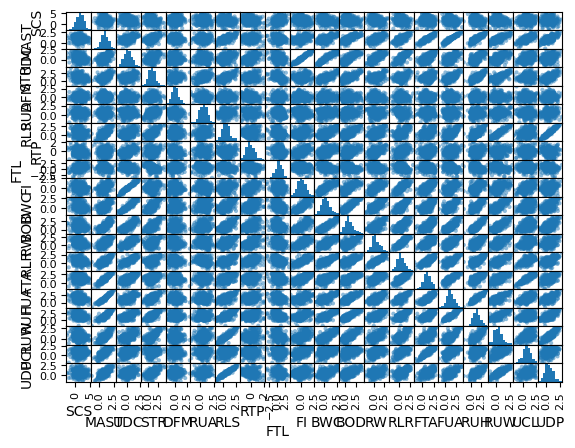

In [ ]:
# Scatterplot para revisar si existe una correlación entre características
pd.plotting.scatter_matrix(selectSiresDf)
plt.show()

In [ ]:
# Mostrar el nivel de correlación para cada característica con respecto a BWC
# calculando la matriz de correlación
correlation_matrix = selectSiresDf.corr()
bwc_correlation = correlation_matrix['BWC']
display(bwc_correlation)

,BWC
SCS,-0.293399
MAST,0.533443
UDC,0.901738
STR,0.665421
DFM,0.023065
RUA,0.136158
RLS,0.546460
RTP,0.433404
FTL,-0.398081
FI,0.773233


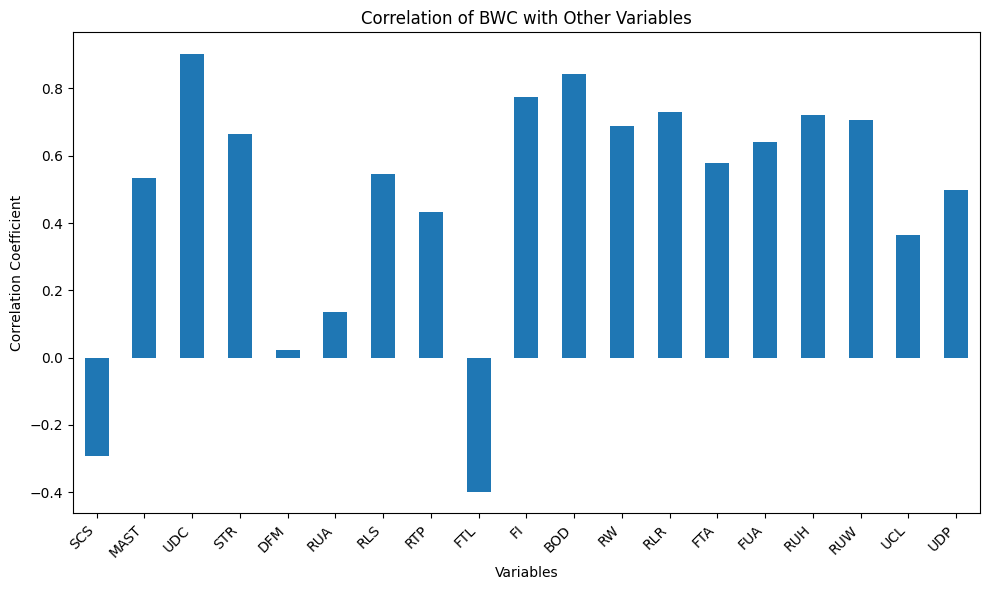

In [ ]:
plt.figure(figsize=(10, 6))
bwc_correlation.drop('BWC').plot(kind='bar', legend=False)
plt.title('Correlation of BWC with Other Variables')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# MODELO BASE: Regresión lineal de BWC vs el resto de variables
y = selectSiresDf['BWC']
X = selectSiresDf.drop(columns=['BWC'])
X = sm.add_constant(X)

In [ ]:
model = sm.OLS(y, X).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BWC   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     1543.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          1.28e-322
Time:                        18:55:18   Log-Likelihood:                 345.13
No. Observations:                 368   AIC:                            -650.3
Df Residuals:                     348   BIC:                            -572.1
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1144      0.018     -6.329      0.000      -0.150      -0.079
SCS            0.0006      0.004      0.147      0.883      -0.008       0.009
MAST           0.6639      0.160      4.153      0.000       0.350       0.978
UDC           -0.0430      0.165     -0.261      0.794      -0.367       0.281
STR            0.8529      0.081     10.505      0.000       0.693       1.013
DFM           -0.0029      0.009     -0.339      0.735      -0.020       0.014
RUA            0.0202      0.011      1.843      0.066      -0.001       0.042
RLS           -0.1099      0.030     -3.656      0.000      -0.169      -0.051
RTP           -0.0051      0.011     -0.463      0.643      -0.027       0.017
FTL           -0.0048      0.005     -0.902      0.368      -0.015       0.006
FI             1.0937      0.195      5.609      0.000       0.710       1.477
BOD           -0.1834      0.038     -4.881      0.000      -0.257      -0.109
RW            -0.0370      0.012     -3.150      0.002      -0.060      -0.014
RLR            0.0434      0.023      1.860      0.064      -0.003       0.089
FTA           -0.0572      0.040     -1.442      0.150      -0.135       0.021
FUA           -0.0231      0.052     -0.449      0.654      -0.125       0.078
RUH           -0.4034      0.038    -10.724      0.000      -0.477      -0.329
RUW            0.0741      0.027      2.719      0.007       0.020       0.128
UCL           -0.3161      0.046     -6.944      0.000      -0.406      -0.227
UDP            0.0640      0.031      2.059      0.040       0.003       0.125
==============================================================================
Omnibus:                       12.790   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.190
Skew:                           0.427   Prob(JB):                      0.00137
Kurtosis:                       3.360   Cond. No.                         260.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

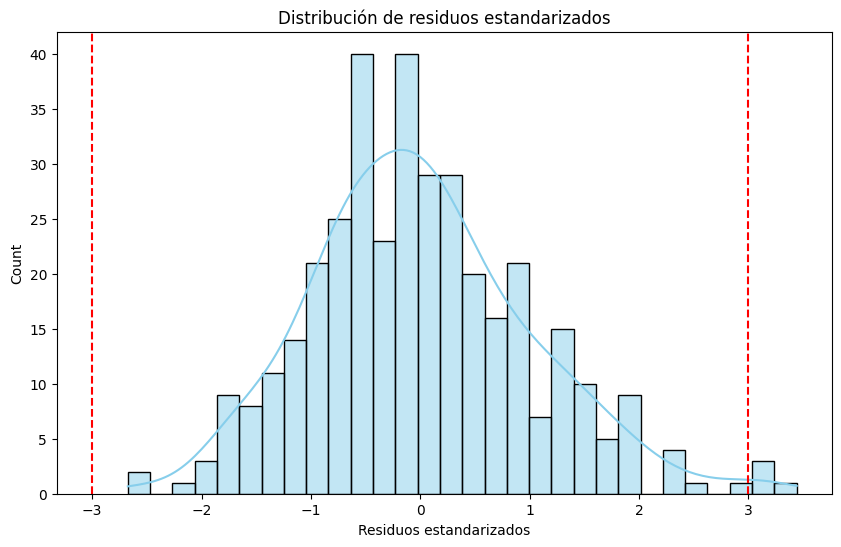

In [ ]:
# Influencia y residuos estandarizados → permite detectar outliers
influence = model.get_influence()
standard_resid = influence.resid_studentized_internal

plt.figure(figsize=(10,6))
sns.histplot(standard_resid, kde=True, bins=30, color='skyblue')
plt.axvline(3, color='r', linestyle='--')
plt.axvline(-3, color='r', linestyle='--')
plt.title('Distribución de residuos estandarizados')
plt.xlabel('Residuos estandarizados')
plt.show()

In [ ]:
outliers_idx = np.where(abs(standard_resid) > 3)[0]
outliers_df = selectSiresDf.iloc[outliers_idx]
print(f"Outliers: {len(outliers_idx)}")
display(outliers_df)

leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

influential_idx = np.where(cooks_d > 4/len(X))[0]
influential_df = selectSiresDf.iloc[influential_idx]
print(f"Puntos influyentes: {len(influential_idx)}")
display(influential_df)

selectSiresDf = selectSiresDf.reset_index(drop=True)

Outliers: 4


,SCS,MAST,UDC,STR,DFM,RUA,RLS,RTP,FTL,FI,BWC,BOD,RW,RLR,FTA,FUA,RUH,RUW,UCL,UDP
2.77,1.3,-1.35,-0.69,-0.05,0.27,-0.20,0.41,1.11,1.1,-0.72,-0.25,-1.09,-0.01,0.35,-1.53,-1.53,-1.91,-0.30,-0.84,-0.14
3.07,1.1,-0.38,0.28,0.54,-0.09,0.68,-1.36,-0.04,0.8,-0.02,0.62,0.04,0.72,-0.08,0.02,-0.07,-0.18,-1.08,-0.55,-0.87
3.15,-2.6,1.64,1.63,1.62,-0.39,-0.12,0.29,0.80,0.3,1.32,2.00,1.83,1.38,1.49,2.08,2.62,3.06,0.76,1.08,0.62
3.03,-1.1,0.95,0.45,1.19,-0.87,0.87,0.38,0.71,-0.2,0.36,0.96,1.21,1.81,0.80,1.29,1.73,1.72,0.53,0.64,0.23


Puntos influyentes: 29


,SCS,MAST,UDC,STR,DFM,RUA,RLS,RTP,FTL,FI,BWC,BOD,RW,RLR,FTA,FUA,RUH,RUW,UCL,UDP
2.87,1.3,-0.25,-0.78,0.44,1.34,1.24,0.50,-1.42,0.9,-1.29,-0.69,-0.92,-0.36,-1.07,-0.64,-0.54,0.42,-0.30,-1.36,0.45
2.59,2.8,1.72,-0.05,-0.32,-0.32,-0.14,0.02,-0.09,1.8,0.33,-0.77,0.87,0.51,0.85,2.07,2.21,1.85,0.46,1.89,-0.23
2.88,0.6,-0.70,-0.01,0.96,1.18,0.12,-0.84,1.96,0.1,-0.15,0.27,0.74,-0.81,-0.55,-1.12,-0.15,0.73,0.12,-0.92,-1.37
2.86,1.6,-0.12,0.66,1.69,-0.23,1.60,1.23,-0.31,-1.4,0.32,1.06,0.71,0.35,0.66,0.59,-0.53,0.08,0.86,0.71,1.15
2.94,-2.0,-0.08,0.41,1.82,-0.80,0.41,-0.16,0.28,-1.6,-0.38,0.22,1.08,-1.12,-1.22,-0.90,0.62,2.25,-1.13,-1.87,-0.62
3.03,0.4,0.69,-0.34,0.59,-0.86,-0.90,-0.06,-1.26,1.8,-0.44,-0.38,0.19,0.37,1.03,0.95,1.26,0.60,0.23,0.85,0.02
3.06,0.4,0.77,0.15,0.59,-0.36,1.70,-0.29,0.10,0.5,0.03,-0.16,-0.12,2.11,0.67,0.59,1.60,1.58,0.31,0.54,-0.32
2.72,0.0,0.17,0.53,0.66,0.82,-0.95,0.49,0.60,-2.2,0.41,0.29,0.57,0.58,0.36,0.27,0.35,0.72,0.41,0.20,0.28
2.59,3.6,1.04,-0.70,-0.65,-1.57,-1.27,0.94,-1.44,0.9,-0.51,-0.94,-0.33,-0.85,0.23,1.25,0.50,0.39,0.71,1.47,0.85
2.75,0.8,0.49,-0.70,2.53,0.16,1.21,2.12,-0.99,2.7,-1.16,0.56,0.72,-1.09,-0.02,0.47,0.76,0.38,1.80,1.21,1.23


In [ ]:
to_remove = np.unique(np.concatenate((outliers_idx, influential_idx)))
valid_idx = [i for i in to_remove if i in selectSiresDf.index]

clean_df = selectSiresDf.drop(index=valid_idx)

print(f"Eliminadas {len(valid_idx)} observaciones.")
print(f"Dataset original: {len(selectSiresDf)}, nuevo: {len(clean_df)}")

y_clean = clean_df['BWC']
X_clean = sm.add_constant(clean_df.drop(columns=['BWC']))
model_clean = sm.OLS(y_clean, X_clean).fit()

comparison = pd.DataFrame({
    'Modelo': ['Original', 'Limpio'],
    'R2 ajustado': [model.rsquared_adj, model_clean.rsquared_adj],
    'AIC': [model.aic, model_clean.aic],
    'BIC': [model.bic, model_clean.bic]
})
print("\n Comparación de modelos")
display(comparison)

Eliminadas 29 observaciones.
Dataset original: 368, nuevo: 339

 Comparación de modelos


,Modelo,R2 ajustado,AIC,BIC
0,Original,0.987625,-650.265501,-572.103843
1,Limpio,0.991617,-742.668101,-666.148099


In [ ]:
print("\n Comparación entre tratamientos")
results = []

y_drop = clean_df['BWC']
X_drop = sm.add_constant(clean_df.drop(columns=['BWC']))
model_drop = sm.OLS(y_drop, X_drop).fit()

results.append({
    'Estrategia': 'Eliminación',
    'R² ajustado': model_drop.rsquared_adj,
    'AIC': model_drop.aic,
    'BIC': model_drop.bic
})

log_df = selectSiresDf.copy()
for col in log_df.columns:
    if col != 'BWC' and (log_df[col] > 0).all():
        log_df[col] = np.log1p(log_df[col])

y_log = log_df['BWC']
X_log = sm.add_constant(log_df.drop(columns=['BWC']))
model_log = sm.OLS(y_log, X_log).fit()

results.append({
    'Estrategia': 'Transformación logarítmica',
    'R² ajustado': model_log.rsquared_adj,
    'AIC': model_log.aic,
    'BIC': model_log.bic
})

winsor_df = selectSiresDf.copy()
for col in winsor_df.columns:
    lower, upper = winsor_df[col].quantile([0.01, 0.99])
    winsor_df[col] = winsor_df[col].clip(lower, upper)

y_wins = winsor_df['BWC']
X_wins = sm.add_constant(winsor_df.drop(columns=['BWC']))
model_wins = sm.OLS(y_wins, X_wins).fit()

results.append({
    'Estrategia': 'Winsorización (1-99%)',
    'R² ajustado': model_wins.rsquared_adj,
    'AIC': model_wins.aic,
    'BIC': model_wins.bic
})

results.append({
    'Estrategia': 'Original',
    'R² ajustado': model.rsquared_adj,
    'AIC': model.aic,
    'BIC': model.bic
})

comparison_df = pd.DataFrame(results).set_index('Estrategia')
comparison_df = comparison_df[
    ['R² ajustado', 'AIC', 'BIC']
    ].sort_values(by='R² ajustado', ascending=False)


print("Resultados comparativos de los modelos:\n")
display(comparison_df.style.background_gradient(cmap="YlGnBu"))


 Comparación entre tratamientos
Resultados comparativos de los modelos:



,R² ajustado,AIC,BIC
Estrategia,,,
Eliminación,0.991617,-742.668101,-666.148099
Transformación logarítmica,0.987625,-650.265501,-572.103843
Original,0.987625,-650.265501,-572.103843
Winsorización (1-99%),0.983028,-540.129498,-461.967839


In [ ]:
# P-values

import statsmodels.api as sm

y = selectSiresDf.iloc[:, 0]
X = selectSiresDf.iloc[:, 1:]

p_values = {}
for col in X.columns:
    X_with_constant = sm.add_constant(X[col])
    model = sm.OLS(y, X_with_constant).fit()
    p_values[col] = model.pvalues[1]

print("P-values:")
for col, p_value in p_values.items():
    print(f"{col}: {p_value:.4f}")

P-values for linear regression of each variable with the first column (BCS):
MAST: 0.0144
UDC: 0.0000
STR: 0.0000
DFM: 0.3549
RUA: 0.9138
RLS: 0.0047
RTP: 0.0004
FTL: 0.0000
FI: 0.0018
BWC: 0.0000
BOD: 0.0001
RW: 0.0000
RLR: 0.0000
FTA: 0.1886
FUA: 0.0000
RUH: 0.0000
RUW: 0.0000
UCL: 0.6421
UDP: 0.0647


/tmp/ipython-input-2929844816.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_values[col] = model.pvalues[1]
/tmp/ipython-input-2929844816.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_values[col] = model.pvalues[1]
/tmp/ipython-input-2929844816.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_values[col] = model.pvalues[1]
/tmp/ipython-input-2929844816.py:14: FutureWarning: Series.__getitem__ treating keys as 

In [ ]:
import statsmodels.api as sm

high_corr_with_bwc = bwc_correlation[
    abs(bwc_correlation) > 0.5].index.tolist()

if 'BWC' in high_corr_with_bwc:
    high_corr_with_bwc.remove('BWC')

y = selectSiresDf['BWC']

X = selectSiresDf[high_corr_with_bwc]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BWC   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2015.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          4.59e-318
Time:                        18:56:15   Log-Likelihood:                 306.56
No. Observations:                 368   AIC:                            -587.1
Df Residuals:                     355   BIC:                            -536.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1734      0.015    -11.584      0.0

In [ ]:
significant_vars = model.pvalues[model.pvalues < 0.05].index.tolist()
significant_vars = [var for var in significant_vars if var != 'const']

X_significant = selectSiresDf[significant_vars]

X_significant = sm.add_constant(X_significant)

model_significant = sm.OLS(y, X_significant).fit()

print("\nResumen modelo con variables significativas (p < 0.05):")
print(model_significant.summary())


Model Summary with Significant Variables (p < 0.05):
                            OLS Regression Results                            
Dep. Variable:                    BWC   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     3021.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          4.94e-324
Time:                        18:56:22   Log-Likelihood:                 304.50
No. Observations:                 368   AIC:                            -591.0
Df Residuals:                     359   BIC:                            -555.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

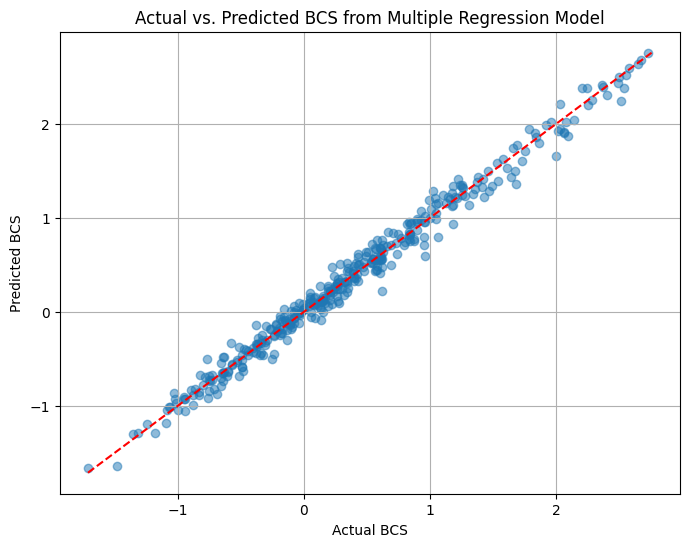

In [ ]:
predictions = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, predictions, alpha=0.5)
plt.xlabel("Actual BCS")
plt.ylabel("Predicted BCS")
plt.title("Actual vs. Predicted BCS from Multiple Regression Model")
plt.grid(True)

min_val = min(y.min(), predictions.min())
max_val = max(y.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.show()

In [ ]:
# Cálculo del VIF (Variance Inflation Factor)
# Indica multicolinealidad entre variables independientes

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_significant.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X_significant.shape[1])]

print("\nMulticollinearity Diagnostics (VIF):")
display(vif_data)


Multicollinearity Diagnostics (VIF):


,feature,VIF
0,const,7.191477
1,MAST,102.394571
2,UDC,129.193229
3,STR,33.601255
4,RLS,7.128504
5,RW,188.601507
6,FUA,13.575697
7,RUH,4.533115
8,RUW,7.557208


In [ ]:
# PCA aplicado solo a variables con VIF > 5
0igh_vif_variables = vif_data[vif_data['VIF'] > 5]['feature'].tolist()
print("Variables with VIF > 5:")
print(high_vif_variables)

Variables with VIF > 5:
['const', 'MAST', 'UDC', 'STR', 'RLS', 'RW', 'FUA', 'RUW']


In [ ]:
high_vif_variables = [var for var in high_vif_variables if var != 'const']
high_vif_df = selectSiresDf[high_vif_variables]
display(high_vif_df.head())

,MAST,UDC,STR,RLS,RW,FUA,RUW
0,0.62,1.39,1.05,0.09,0.25,0.79,0.07
1,0.98,-0.23,1.52,0.76,0.14,1.48,0.47
2,0.43,-0.75,1.38,-0.81,-0.52,0.39,-0.28
3,0.89,0.05,0.21,0.40,0.96,0.96,0.32
4,0.52,-0.73,0.04,0.00,0.15,0.29,-0.18


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(high_vif_df)

principal_components_df = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(principal_components.shape[1])])

print("Explained variance ratio by each principal component:")
display(pd.DataFrame(pca.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(principal_components.shape[1])], columns=['Explained Variance Ratio']))

display(principal_components_df.head())

Explained variance ratio by each principal component:


,Explained Variance Ratio
PC1,0.628964
PC2,0.160882
PC3,0.081704
PC4,0.066315
PC5,0.047483


,PC1,PC2,PC3,PC4,PC5
0,-0.391081,0.546584,-0.624545,0.468968,0.959516
1,0.029620,-0.774174,0.215154,0.278639,-0.212554
2,-2.004540,-0.483517,0.076094,1.082538,-0.306821
3,-0.413185,0.607028,-0.089395,-0.516439,-0.449911
4,-1.837152,0.149647,-0.056148,-0.394576,-0.629861


In [ ]:
low_vif_variables = [col for col in selectSiresDf.columns if col not in high_vif_variables and col != 'BWC']

low_vif_df = selectSiresDf[low_vif_variables]

X_pca_combined = pd.concat([principal_components_df, low_vif_df], axis=1)

display(X_pca_combined.head())

,PC1,PC2,PC3,PC4,PC5,SCS,DFM,RUA,RTP,FTL,FI,BOD,RLR,FTA,RUH,UCL,UDP
0,-0.391081,0.546584,-0.624545,0.468968,0.959516,2.3,0.06,1.50,0.55,0.3,1.13,1.31,0.42,1.26,1.33,0.80,0.22
1,0.029620,-0.774174,0.215154,0.278639,-0.212554,1.5,0.27,0.72,-0.41,0.7,-0.60,0.75,0.26,0.92,1.61,0.54,0.44
2,-2.004540,-0.483517,0.076094,1.082538,-0.306821,3.5,0.54,0.35,-0.32,0.4,-1.18,0.12,-0.45,0.73,0.80,0.59,-0.36
3,-0.413185,0.607028,-0.089395,-0.516439,-0.449911,2.9,-0.41,-0.02,-0.03,1.6,-0.03,0.52,0.50,0.87,1.10,0.51,0.31
4,-1.837152,0.149647,-0.056148,-0.394576,-0.629861,2.5,0.60,0.71,-0.62,1.1,-0.72,0.16,-0.23,0.77,0.44,0.51,0.14


In [ ]:
import statsmodels.api as sm

y = selectSiresDf['BWC']
X_pca_combined = sm.add_constant(X_pca_combined)
model_pca = sm.OLS(y, X_pca_combined).fit()

print(model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:                    BWC   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1603.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          5.68e-320
Time:                        19:18:11   Log-Likelihood:                 330.89
No. Observations:                 368   AIC:                            -625.8
Df Residuals:                     350   BIC:                            -555.4
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7914      0.052     15.305      0.0

In [ ]:
results = [
    {
        'Estrategia': 'Eliminación',
        'R² ajustado': model_drop.rsquared_adj,
        'AIC': model_drop.aic,
        'BIC': model_drop.bic
    },
    {
        'Estrategia': 'Transformación logarítmica',
        'R² ajustado': model_log.rsquared_adj,
        'AIC': model_log.aic,
        'BIC': model_log.bic
    },
    {
        'Estrategia': 'Winsorización (1-99%)',
        'R² ajustado': model_wins.rsquared_adj,
        'AIC': model_wins.aic,
        'BIC': model_wins.bic
    },
    {
        'Estrategia': 'Original',
        'R² ajustado': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    }
]

comparison_df = pd.DataFrame(results).set_index('Estrategia')

pca_metrics = {
    'Estrategia': 'PCA Combined Model',
    'R² ajustado': model_pca.rsquared_adj,
    'AIC': model_pca.aic,
    'BIC': model_pca.bic
}

comparison_df = pd.concat([comparison_df, pd.DataFrame([pca_metrics]).set_index('Estrategia')])

comparison_df = comparison_df.sort_values(by='R² ajustado', ascending=False)

print("\nResultados comparativos de los modelos:\n")
display(comparison_df.style.background_gradient(cmap="YlGnBu"))


Resultados comparativos de los modelos:



,R² ajustado,AIC,BIC
Estrategia,,,
Eliminación,0.991617,-742.668101,-666.148099
Transformación logarítmica,0.987625,-650.265501,-572.103843
PCA Combined Model,0.986705,-625.771566,-555.426073
Original,0.985040,-587.126582,-536.321504
Winsorización (1-99%),0.983028,-540.129498,-461.967839
